<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-19</br>
</div>

</br>

In [17]:
# TODO 0: 실습을 위해 아래 패키지를 import 해주세요.
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: mps


</br>

# 학습 내용
>이번 장에서는 <strong>Fine-tuning과 데이터 증강(Fine-tuning & Data Augmentation)</strong>에 대해 학습합니다.</br></br>
>모델 전체를 미세 조정하고, 데이터 증강으로 학습 데이터를 학습해봅시다.</br></br>

</br>

# Fine-tuning (미세 조정)
> 사전학습 모델의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">모든 가중치를 동결 해제(Unfreeze)</mark>하고 새 태스크에 맞게 재학습합니다.</br></br>

> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Linear Probing</mark>은 사전학습된 백본을 완전히 동결하고 마지막 분류 헤드만 학습하는 반면, **Fine-tuning**은 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">백본 전체의 가중치를 함께 업데이트</mark>하여 새로운 태스크에 맞게 모델 전체를 적응시킵니다.</br></br>
> 실제 학습 데이터는 대부분 부족하므로, 과적합을 방지하고 일반화 성능을 높이려면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">회전 / 좌우 반전 / 색상 변환</mark> 등의 변환으로 동일한 이미지를 다양하게 변형하여 데이터 다양성을 인위적으로 확보하는 **데이터 증강**이 함께 필요합니다.</br>

In [18]:
# TODO 1: ResNet18 사전학습 모델을 로드하고, 모든 파라미터에 대해 동결을 해제하여 학습 가능한 파라미터 수를 출력해봅시다.

import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 10)

for param in model.parameters():
    param.requires_grad = True

trainable = sum(param.numel() for param in model.parameters() if param.requires_grad)
total_count = sum(param.numel() for param in model.parameters())
print(f"학습 파라미터: {trainable:,} / {total_count:,} ({trainable/total_count:.0%})")

학습 파라미터: 11,181,642 / 11,181,642 (100%)


</br>

## Linear Probing vs Fine-tuning

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">비교 항목</th>
      <th>Linear Probing</th>
      <th>Fine-tuning</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">학습 범위</td><td>fc 레이어만</td><td><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">전체 모델</mark></td></tr>
    <tr><td style="text-align:center">학습 속도</td><td>빠름</td><td>느림</td></tr>
    <tr><td style="text-align:center">필요 데이터량</td><td>적음</td><td>많음</td></tr>
    <tr><td style="text-align:center">과적합 위험</td><td>낮음</td><td>높음</td></tr>
    <tr><td style="text-align:center">최종 성능</td><td>보통</td><td><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">일반적으로 높음</mark></td></tr>
  </tbody>
</table>

💡학습률 차이
> Fine-tuning 시 사전학습 레이어는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">작은 학습률</mark>(1e-4~1e-5)을 사용합니다.</br>
> 새로 추가한 fc 레이어는 상대적으로 큰 학습률(1e-3)을 사용합니다.</br></br>

</br>

# 데이터 증강 (Data Augmentation)
> 학습 이미지에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">랜덤 변형을 적용</mark>하여 데이터 다양성을 높이고 과적합을 방지합니다.</br></br>

<div style="text-align:center">

</div>

In [19]:
# TODO 2: 학습용 전처리 파이프라인을 구성해봅시다.

# TODO 2-1: RandomResizedCrop(224)을 추가해봅시다. — 랜덤 위치/크기로 잘라서 224x224로 리사이즈
# TODO 2-2: RandomHorizontalFlip(p=0.5)을 추가해봅시다. — 50% 확률로 좌우 반전
# TODO 2-3: RandomRotation(15)을 추가해봅시다. — ±15° 범위에서 랜덤 회전
# TODO 2-4: ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)를 추가해봅시다. — 밝기/대비/채도 ±20% 조정
# TODO 2-5: ToTensor()와 ImageNet Normalize를 추가해봅시다. — PIL→텐서 변환 + 평균/표준편차 정규화

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print(f"학습 전처리: {train_transform}")

학습 전처리: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


<div style="text-align:center">

</div>

In [20]:
# TODO 3: 검증용 전처리에는 Resize(256), CenterCrop(224), ToTensor, Normalize만 적용해봅시다.

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print(f"검증 전처리: {val_transform}")

검증 전처리: Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


</br>

## 주요 증강 기법

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">기법</th>
      <th>설명</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center"><code>RandomCrop</code></td><td>랜덤 위치에서 자르기</td></tr>
    <tr><td style="text-align:center"><code>RandomHorizontalFlip</code></td><td>좌우 반전 (p=0.5)</td></tr>
    <tr><td style="text-align:center"><code>RandomRotation</code></td><td>랜덤 회전</td></tr>
    <tr><td style="text-align:center"><code>ColorJitter</code></td><td>밝기, 대비, 채도 변형</td></tr>
    <tr><td style="text-align:center"><code>RandomErasing</code></td><td>랜덤 영역 마스킹</td></tr>
  </tbody>
</table>

💡검증 데이터에 증강 금지
> 검증과 테스트 데이터에는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">증강을 적용하지 않습니다</mark>.</br>
> Resize + CenterCrop + Normalize만 적용하여 일관된 평가를 보장합니다.</br></br>

💡어떤 증강을 선택할까?
> 도메인에 맞는 변형만 적용합니다.</br>
> 예: 의료 이미지에서 좌우 반전은 의미가 있지만, <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">상하 반전은 부적절</mark>할 수 있습니다.</br></br>

</br>

# 데이터 준비
> CIFAR-10 데이터셋을 로드하고, 앞서 정의한 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">데이터 증강 파이프라인</mark>을 적용하여 학습/테스트 DataLoader를 구성합니다.</br></br>

In [21]:
# TODO 4: train_dataset에 CIFAR-10 학습 데이터를 로드해봅시다. (train_transform 적용)
train_dataset = torchvision.datasets.CIFAR10(root="../data", train=True, download=True, transform=train_transform)

In [22]:
# TODO 5: test_dataset에 CIFAR-10 테스트 데이터를 로드해봅시다. (val_transform 적용)
test_dataset = torchvision.datasets.CIFAR10(root="../data", train=False, download=True, transform=val_transform)

In [23]:
# TODO 6: train_loader를 생성해봅시다. (batch_size=256, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)

In [24]:
# TODO 7: test_loader를 생성해봅시다. (batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

print(f"학습: {len(train_dataset)}개, 테스트: {len(test_dataset)}개")

학습: 50000개, 테스트: 10000개


</br>

# Full Fine-tuning 학습
> 사전학습된 ResNet18의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">모든 레이어를 동결 해제(Unfreeze)</mark>하고, CIFAR-10 데이터셋에 맞게 전체 모델을 재학습합니다.</br></br>
> 모든 가중치가 업데이트되므로 표현력이 높지만, <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">학습 시간이 길고 과적합 위험</mark>이 있습니다.</br></br>

In [25]:
# TODO 8: ResNet18 사전학습 모델을 로드해봅시다.
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

In [26]:
# TODO 9: fc 레이어를 10 클래스에 맞게 교체해봅시다.
model.fc = nn.Linear(model.fc.in_features, 10)

In [27]:
# TODO 10: 모든 파라미터의 동결을 해제해봅시다.
for param in model.parameters():
    param.requires_grad = True

trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
print(f"학습 파라미터: {trainable_params:,}")

model = model.to(device)

학습 파라미터: 11,181,642


In [28]:
# TODO 11: cross_entropy에 CrossEntropyLoss를 저장해봅시다.
cross_entropy = nn.CrossEntropyLoss()

💡`nn.CrossEntropyLoss()`란?
> 분류 문제에서 가장 많이 쓰는 손실 함수입니다.</br></br>
> 모델의 예측 확률과 실제 정답을 비교하여 "얼마나 틀렸는지"를 숫자로 계산합니다.</br></br>
> 내부적으로 `Softmax + NLLLoss`를 합친 것이라 별도의 Softmax 레이어가 필요 없습니다.

In [29]:
# TODO 12: optimizer에 SGD를 저장해봅시다. (lr=0.0005, momentum=0.9)
optimizer = optim.SGD(model.parameters(), lr=0.0005, momentum=0.9)

💡`optim.SGD()`란?
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">확률적 경사 하강법(Stochastic Gradient Descent)</mark> 옵티마이저입니다.</br></br>
> `lr` (학습률): 파라미터를 한 번에 얼마나 조정할지 결정합니다. 너무 크면 발산, 너무 작으면 학습이 느립니다.</br></br>
> `momentum`: 이전 업데이트 방향을 기억하여 같은 방향이면 가속합니다. 보통 0.9를 사용합니다.</br></br>

In [30]:
# TODO 13: scheduler에 StepLR을 저장해봅시다. (step_size=5, gamma=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

💡`StepLR` 스케줄러란?
> 학습이 진행될수록 학습률을 점차 줄여주는 도구입니다.</br></br>
> `step_size=2`: 2 에폭마다 학습률을 줄입니다.</br></br>
> `gamma=0.1`: 줄일 때 현재 학습률의 10%로 감소시킵니다.</br></br>
> 처음에는 크게 학습하고, 나중에는 세밀하게 조정하는 효과가 있습니다.</br></br>

In [31]:
# TODO 14: Full Fine-tuning 학습 루프 (5 epochs)

epochs = 5
for epoch in range(epochs):

    # TODO 14-1: 모델을 학습 모드로 전환해봅시다.
    model.train()
    running_loss = 0.0
    correct_count = 0
    total_count = 0

    for images, labels in train_loader:

        # TODO 14-2: 데이터를 디바이스로 이동해봅시다.
        images, labels = images.to(device), labels.to(device)

        # TODO 14-3: 기울기를 초기화해봅시다.
        optimizer.zero_grad()  # 이전 배치의 기울기 초기화

        # TODO 14-4: 순전파를 수행해봅시다.
        outputs = model(images)  # 순전파: 입력 → 레이어 통과 → 예측값

        # TODO 14-5: 손실을 계산해봅시다.
        loss = cross_entropy(outputs, labels)  # 예측 vs 정답 비교 → 오차 측정

        # TODO 14-6: 역전파를 수행해봅시다.
        loss.backward()  # 역전파: 각 파라미터의 기울기 계산

        # TODO 14-7: 파라미터를 업데이트해봅시다.
        optimizer.step()  # 기울기 방향으로 파라미터 업데이트

        # TODO 14-8: 배치별 손실과 정확도를 누적해봅시다.
        running_loss += loss.item() * labels.size(0)  # 배치 평균 손실 × 샘플 수 = 배치 총 손실
        _, predicted = outputs.max(1)
        total_count += labels.size(0)
        correct_count += predicted.eq(labels).sum().item()

    # TODO 14-9: 에폭 종료 후 스케줄러를 업데이트해봅시다.
    scheduler.step()
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}, Acc: {100.*correct_count/total_count:.2f}%")

Epoch [1/5] Loss: 439.8104, Acc: 41.19%
Epoch [2/5] Loss: 288.9231, Acc: 61.41%
Epoch [3/5] Loss: 241.5516, Acc: 67.46%
Epoch [4/5] Loss: 214.9020, Acc: 71.04%
Epoch [5/5] Loss: 199.1876, Acc: 72.94%


In [32]:
# TODO 15: 모델을 평가 모드로 전환하고, 테스트 데이터로 정확도를 계산해봅시다.

model.eval()
correct_count = 0
total_count = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total_count += labels.size(0)
        correct_count += predicted.eq(labels).sum().item()
full_ft_accuracy = 100. * correct_count / total_count
print(f"Full Fine-tuning 테스트 정확도: {full_ft_accuracy:.2f}%")

Full Fine-tuning 테스트 정확도: 88.13%


</br>

# Partial Fine-tuning (layer4 + fc)
> 사전학습된 ResNet18에서 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">layer1~layer3은 동결</mark>하고, <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">layer4와 fc만 학습</mark>합니다.</br></br>
> 낮은 레이어(layer1~3)는 일반적인 시각 특성(edge, texture)을 이미 잘 학습한 상태이므로 보존하고, 높은 레이어(layer4)만 새 태스크에 맞게 재조정합니다.</br></br>

In [33]:
# TODO 16: 새로운 ResNet18 사전학습 모델을 로드해봅시다.
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

In [34]:
# TODO 17: fc 레이어를 10 클래스에 맞게 교체해봅시다.
model.fc = nn.Linear(model.fc.in_features, 10)

In [35]:
# TODO 18: 모든 파라미터를 동결해봅시다.
for param in model.parameters():
    param.requires_grad = False

In [36]:
# TODO 19: model.layer4의 파라미터를 동결 해제해봅시다.
for param in model.layer4.parameters():
    param.requires_grad = True

In [37]:
# TODO 20: model.fc의 파라미터를 동결 해제해봅시다.
for param in model.fc.parameters():
    param.requires_grad = True

In [38]:
# TODO 21: 학습 가능한 파라미터 수를 출력해봅시다.
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)
total_params = sum(param.numel() for param in model.parameters())
print(f"학습 파라미터: {trainable_params:,} / {total_params:,} ({trainable_params/total_params:.1%})")

model = model.to(device)

학습 파라미터: 8,398,858 / 11,181,642 (75.1%)


💡`numel()`이란?
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Number of Elements</mark>의 약자로, 텐서 안에 들어있는 숫자의 총 개수를 반환합니다.</br></br>
> 예: `(3, 4)` 크기의 텐서 → `numel() = 12`</br></br>
> 모델의 파라미터 수를 셀 때 `sum(p.numel() for p in model.parameters())`처럼 사용합니다.

</br>

# Optimizer / Scheduler 비교
> Partial Fine-tuning 모델에 서로 다른 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Optimizer + Scheduler 조합</mark>을 적용하여 학습 성능을 비교합니다.</br></br>

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">조합</th>
      <th style="text-align:center">Optimizer</th>
      <th style="text-align:center">특징</th>
      <th style="text-align:center">Scheduler</th>
      <th style="text-align:center">특징</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align:center"><strong>Baseline</strong></td>
      <td style="text-align:center">SGD + Momentum</td>
      <td style="text-align:center">안정적 수렴, 일반화 우수</td>
      <td style="text-align:center">StepLR</td>
      <td style="text-align:center">고정 주기로 학습률 감소</td>
    </tr>
    <tr>
      <td style="text-align:center"><strong>Experiment</strong></td>
      <td style="text-align:center">Adam</td>
      <td style="text-align:center">적응적 학습률, 빠른 수렴</td>
      <td style="text-align:center">ReduceLROnPlateau</td>
      <td style="text-align:center">손실 기반 적응적 감소</td>
    </tr>
  </tbody>
</table>

In [39]:
# TODO 22: initial_state에 모델 초기 상태를 저장해봅시다. (copy.deepcopy)
initial_state = copy.deepcopy(model.state_dict())

In [40]:
# TODO 23: cross_entropy에 CrossEntropyLoss를 저장해봅시다.
cross_entropy = nn.CrossEntropyLoss()

In [41]:
# TODO 24: optimizer에 SGD를 저장해봅시다. (lr=0.001, momentum=0.9)
# requires_grad=True인 파라미터만 필터링하여 옵티마이저에 전달
# 동결된 파라미터는 업데이트할 필요가 없으므로 제외
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

In [42]:
# TODO 25: scheduler에 StepLR을 저장해봅시다. (step_size=5, gamma=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [43]:
# TODO 26: SGD+StepLR 학습 루프 (조합 A) (10 epochs)

epochs = 10
sgd_train_loss_list = []

for epoch in range(epochs):

    # TODO 26-1: 모델을 학습 모드로 전환해봅시다.
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        # TODO 26-2: 데이터를 디바이스로 이동해봅시다.
        images, labels = images.to(device), labels.to(device)

        # TODO 26-3: 기울기를 초기화해봅시다.
        optimizer.zero_grad()  # 이전 배치의 기울기 초기화

        # TODO 26-4: 순전파를 수행해봅시다.
        outputs = model(images)  # 순전파: 입력 → 레이어 통과 → 예측값

        # TODO 26-5: 손실을 계산해봅시다.
        loss = cross_entropy(outputs, labels)  # 예측 vs 정답 비교 → 오차 측정

        # TODO 26-6: 역전파를 수행해봅시다.
        loss.backward()  # 역전파: 각 파라미터의 기울기 계산

        # TODO 26-7: 파라미터를 업데이트해봅시다.
        optimizer.step()  # 기울기 방향으로 파라미터 업데이트

        # TODO 26-8: 배치별 손실을 누적해봅시다.
        running_loss += loss.item() * labels.size(0)  # 배치 평균 손실 × 샘플 수 = 배치 총 손실

    # TODO 26-9: 에폭 종료 후 스케줄러를 업데이트해봅시다.
    scheduler.step()
    epoch_loss = running_loss / total_count
    sgd_train_loss_list.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/10] Loss: 8.1306
Epoch [2/10] Loss: 5.7980
Epoch [3/10] Loss: 5.2082
Epoch [4/10] Loss: 4.8752
Epoch [5/10] Loss: 4.6689
Epoch [6/10] Loss: 4.5465
Epoch [7/10] Loss: 4.5672
Epoch [8/10] Loss: 4.5352
Epoch [9/10] Loss: 4.5287
Epoch [10/10] Loss: 4.5118


In [44]:
# TODO 27: SGD+StepLR 모델을 평가 모드로 전환하고, 테스트 정확도를 계산해봅시다.

model.eval()
correct_count = 0
total_count = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = model(images).max(1)
        total_count += labels.size(0)
        correct_count += predicted.eq(labels).sum().item()
baseline_accuracy = 100. * correct_count / total_count
print(f"Baseline (SGD+StepLR) 정확도: {baseline_accuracy:.2f}%")

Baseline (SGD+StepLR) 정확도: 85.25%


In [45]:
# TODO 28: 초기 상태로 모델을 복원해봅시다.
model.load_state_dict(initial_state)

<All keys matched successfully>

In [46]:
# TODO 29: optimizer에 Adam을 저장해봅시다. (lr=0.001)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

In [47]:
# TODO 30: scheduler에 ReduceLROnPlateau를 저장해봅시다.
# mode="min": loss가 줄어드는 것을 개선으로 판단 ("max"면 accuracy처럼 높아지는 것을 개선으로 판단)
# factor=0.1: 개선이 없으면 학습률을 현재의 10%로 감소
# patience=2: 2 에폭 연속 개선이 없을 때 감소 실행
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)

In [48]:
# TODO 31: Adam+ReduceLR 학습 루프 (조합 B) (10 epochs)

epochs = 10
adam_train_loss_list = []

for epoch in range(epochs):

    # TODO 31-1: 모델을 학습 모드로 전환해봅시다.
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        # TODO 31-2: 데이터를 디바이스로 이동해봅시다.
        images, labels = images.to(device), labels.to(device)

        # TODO 31-3: 기울기를 초기화해봅시다.
        optimizer.zero_grad()  # 이전 배치의 기울기 초기화

        # TODO 31-4: 순전파를 수행해봅시다.
        outputs = model(images)  # 순전파: 입력 → 레이어 통과 → 예측값

        # TODO 31-5: 손실을 계산해봅시다.
        loss = cross_entropy(outputs, labels)  # 예측 vs 정답 비교 → 오차 측정

        # TODO 31-6: 역전파를 수행해봅시다.
        loss.backward()  # 역전파: 각 파라미터의 기울기 계산

        # TODO 31-7: 파라미터를 업데이트해봅시다.
        optimizer.step()  # 기울기 방향으로 파라미터 업데이트

        # TODO 31-8: 배치별 손실을 누적해봅시다.
        running_loss += loss.item() * labels.size(0)  # 배치 평균 손실 × 샘플 수 = 배치 총 손실

    epoch_loss = running_loss / total_count
    adam_train_loss_list.append(epoch_loss)

    # TODO 31-9: ReduceLROnPlateau는 epoch_loss를 전달하여 스케줄러를 업데이트해봅시다.
    scheduler.step(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/10] Loss: 4.8533
Epoch [2/10] Loss: 3.9106
Epoch [3/10] Loss: 3.6467
Epoch [4/10] Loss: 3.4525
Epoch [5/10] Loss: 3.2765
Epoch [6/10] Loss: 3.1679
Epoch [7/10] Loss: 3.1009
Epoch [8/10] Loss: 2.9400
Epoch [9/10] Loss: 2.9265
Epoch [10/10] Loss: 2.8302


In [49]:
# TODO 32: Adam+ReduceLR 모델을 평가 모드로 전환하고, 테스트 정확도를 계산해봅시다.

model.eval()
correct_count = 0
total_count = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = model(images).max(1)
        total_count += labels.size(0)
        correct_count += predicted.eq(labels).sum().item()
experiment_accuracy = 100. * correct_count / total_count
print(f"Experiment (Adam+ReduceLR) 정확도: {experiment_accuracy:.2f}%")

Experiment (Adam+ReduceLR) 정확도: 92.00%


</br>

# 학습 곡선 비교
> 두 가지 Optimizer/Scheduler 조합의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">학습 곡선(Train Loss)</mark>과 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">테스트 정확도</mark>를 시각적으로 비교합니다.</br></br>

/Users/sahong.pak/Documents/AI/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sahong.pak/Documents/AI/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sahong.pak/Documents/AI/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sahong.pak/Documents/AI/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


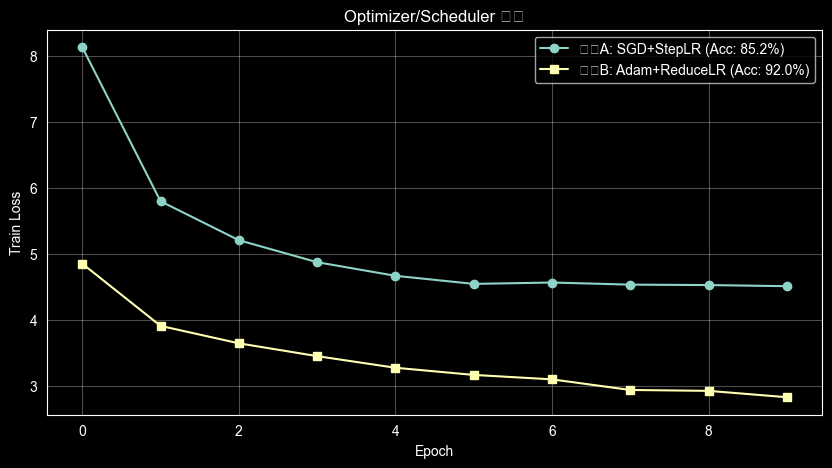

In [50]:
# TODO 33: 학습 곡선을 비교 시각화해봅시다.

plt.figure(figsize=(10, 5))
plt.plot(sgd_train_loss_list, label=f"조합A: SGD+StepLR (Acc: {baseline_accuracy:.1f}%)", marker="o")
plt.plot(adam_train_loss_list, label=f"조합B: Adam+ReduceLR (Acc: {experiment_accuracy:.1f}%)", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Optimizer/Scheduler 비교")
plt.legend()
plt.grid(alpha=0.3)
plt.show()